### Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import (LinearRegression, LassoCV, ElasticNetCV,
                                   RidgeCV, Lasso, ElasticNet)

import statsmodels.api as sm
from scipy import stats

### Data and Descriptive Analysis

In [34]:
df = pd.read_csv("../Data/communities_crime.csv")
df.describe()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,pctWFarmSelf,pctWInvInc,pctWSocSec,pctWPubAsst,pctWRetire,medFamInc,perCapInc,whitePerCap,blackPerCap,indianPerCap,AsianPerCap,OtherPerCap,HispPerCap,NumUnderPov,PctPopUnderPov,PctLess9thGrade,PctNotHSGrad,PctBSorMore,PctUnemployed,PctEmploy,PctEmplManu,PctEmplProfServ,PctOccupManu,PctOccupMgmtProf,MalePctDivorce,MalePctNevMarr,FemalePctDiv,TotalPctDiv,PersPerFam,PctFam2Par,PctKids2Par,PctYoungKids2Par,PctTeen2Par,PctWorkMomYoungKids,PctWorkMom,NumIlleg,PctIlleg,NumImmig,PctImmigRecent,PctImmigRec5,PctImmigRec8,PctImmigRec10,PctRecentImmig,PctRecImmig5,PctRecImmig8,PctRecImmig10,PctSpeakEnglOnly,PctNotSpeakEnglWell,PctLargHouseFam,PctLargHouseOccup,PersPerOccupHous,PersPerOwnOccHous,PersPerRentOccHous,PctPersOwnOccup,PctPersDenseHous,PctHousLess3BR,MedNumBR,HousVacant,PctHousOccup,PctHousOwnOcc,PctVacantBoarded,PctVacMore6Mos,MedYrHousBuilt,PctHousNoPhone,PctWOFullPlumb,OwnOccLowQuart,OwnOccMedVal,OwnOccHiQuart,RentLowQ,RentMedian,RentHighQ,MedRent,MedRentPctHousInc,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000
mean,0.057593,0.463395,0.179629,0.753716,0.153681,0.144022,0.424218,0.493867,0.336264,0.423164,0.064072,0.696269,0.361123,0.558154,0.291570,0.495687,0.471133,0.317778,0.479248,0.375677,0.350251,0.368049,0.291098,0.203506,0.322357,0.284724,0.386279,0.055507,0.303024,0.315807,0.383330,0.361675,0.363531,0.501073,0.396384,0.440597,0.391224,0.441339,0.461244,0.434453,0.487568,0.494273,0.487748,0.610918,0.620657,0.664032,0.582884,0.501449,0.526690,0.036294,0.249995,0.030060,0.320211,0.360622,0.399077,0.427879,0.181364,0.182126,0.184774,0.182879,0.785903,0.150587,0.267608,0.251891,0.462101,0.494428,0.404097,0.562598,0.186264,0.495186,0.314694,0.076815,0.719549,0.548686,0.204529,0.433335,0.494178,0.264478,0.243059,0.264689,0.263490,0.268942,0.346379,0.372457,0.422964,0.384102,0.490125,0.449754,0.403816,0.029438,0.022778,0.215552,0.608892,0.535050,0.626424,0.651530,0.065231,0.232854,0.161685,0.094052,0.237979
std,0.126906,0.163717,0.253442,0.244039,0.208877,0.232492,0.155196,0.143564,0.166505,0.179185,0.128256,0.444811,0.209362,0.182913,0.204108,0.178071,0.173619,0.222137,0.167564,0.198257,0.191109,0.186804,0.171593,0.164775,0.195411,0.190962,0.183081,0.127941,0.228474,0.213360,0.202508,0.209193,0.202171,0.174036,0.202386,0.175457,0.198922,0.186292,0.182460,0.175437,0.175170,0.183607,0.154594,0.201976,0.206353,0.218749,0.191507,0.168612,0.175241,0.108671,0.229946,0.087189,0.219088,0.210924,0.201498,0.194970,0.2357

In [35]:
df.head()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,pctWFarmSelf,pctWInvInc,pctWSocSec,pctWPubAsst,pctWRetire,medFamInc,perCapInc,whitePerCap,blackPerCap,indianPerCap,AsianPerCap,OtherPerCap,HispPerCap,NumUnderPov,PctPopUnderPov,PctLess9thGrade,PctNotHSGrad,PctBSorMore,PctUnemployed,PctEmploy,PctEmplManu,PctEmplProfServ,PctOccupManu,PctOccupMgmtProf,MalePctDivorce,MalePctNevMarr,FemalePctDiv,TotalPctDiv,PersPerFam,PctFam2Par,PctKids2Par,PctYoungKids2Par,PctTeen2Par,PctWorkMomYoungKids,PctWorkMom,NumIlleg,PctIlleg,NumImmig,PctImmigRecent,PctImmigRec5,PctImmigRec8,PctImmigRec10,PctRecentImmig,PctRecImmig5,PctRecImmig8,PctRecImmig10,PctSpeakEnglOnly,PctNotSpeakEnglWell,PctLargHouseFam,PctLargHouseOccup,PersPerOccupHous,PersPerOwnOccHous,PersPerRentOccHous,PctPersOwnOccup,PctPersDenseHous,PctHousLess3BR,MedNumBR,HousVacant,PctHousOccup,PctHousOwnOcc,PctVacantBoarded,PctVacMore6Mos,MedYrHousBuilt,PctHousNoPhone,PctWOFullPlumb,OwnOccLowQuart,OwnOccMedVal,OwnOccHiQuart,RentLowQ,RentMedian,RentHighQ,MedRent,MedRentPctHousInc,MedOwnCostPctInc,MedOwnCostPctIncNoMtg,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop,HighViolentCrime
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,0.20,1.0,0.37,0.72,0.34,0.60,0.29,0.15,0.43,0.39,0.40,0.39,0.32,0.27,0.27,0.36,0.41,0.08,0.19,0.10,0.18,0.48,0.27,0.68,0.23,0.41,0.25,0.52,0.68,0.40,0.75,0.75,0.35,0.55,0.59,0.61,0.56,0.74,0.76,0.04,0.14,0.03,0.24,0.27,0.37,0.39,0.07,0.07,0.08,0.08,0.89,0.06,0.14,0.13,0.33,0.39,0.28,0.55,0.09,0.51,0.5,0.21,0.71,0.52,0.05,0.26,0.65,0.14,0.06,0.22,0.19,0.18,0.36,0.35,0.38,0.34,0.38,0.46,0.25,0.04,0.0,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20,High
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,0.02,1.0,0.31,0.72,0.11,0.45,0.25,0.29,0.39,0.29,0.37,0.38,0.33,0.16,0.30,0.22,0.35,0.01,0.24,0.14,0.24,0.30,0.27,0.73,0.57,0.15,0.42,0.36,1.00,0.63,0.91,1.00,0.29,0.43,0.47,0.60,0.39,0.46,0.53,0.00,0.24,0.01,0.52,0.62,0.64,0.63,0.25,0.27,0.25,0.23,0.84,0.10,0.16,0.10,0.17,0.29,0.17,0.26,0.20,0.82,0.0,0.02,0.79,0.24,0.02,0.25,0.65,0.16,0.00,0.21,0.20,0.21,0.42,0.38,0.40,0.37,0.29,0.32,0.18,0.00,0.0,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67,High
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,0.00,0.0,0.30,0.58,0.19,0.39,0.38,0.40,0.84,0.28,0.27,0.29,0.27,0.07,0.29,0.28,0.39,0.01,0.27,0.27,0.43,0.19,0.36,0.58,0.32,0.29,0.49,0.32,0.63,0.41,0.71,0.70,0.45,0.42,0.44,0.43,0.43,0.71,0.67,0.01,0.46,0.00,0.07,0.06,0.15,0.19,0.02,0.02,0.04,0.05,0.88,0.04,0.20,0.20,0.46,0.52,0.43,0.42,0.15,0.51,0.5,0.01,0.86,0.41,0.29,0.30,0.52,0.47,0.45,0.18,0.17,0.16,0.27,0.29,0.27,0.31,0.48,0.39,0.28,0.00,0.0,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43,High
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,0.06,1.0,0.58,0.89,0.21,0.43,0.36,0.20,0.82,0.51,0.36,0.40,0.39,0.16,0.25,0.36,0.44,0.01,0.10,0.09,0.25,0.31,0.33,0.71,0.36,0.45,0.37,0.39,0.34,0.45,0.49,0.44,0.75,0.65,0.54,0.83,0.65,0.85,0.86,0.03,0.33,0.02,0.11,0.20,0.30,0.31,0.05,0.08,0.11,0.11,0.81,0.08,0.56,0.62,0.85,0.77,1.00,0.94,0.12,0.01,0.5,0.01,0.97,0.96,0.60,0.47,0.52,0.11,0.11,0.24,0.21,0.19,0.75,0.70,0.77,0.89,0.63,0.51,0.47,0.00,0.0,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12,Low
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,0.02,0.9,0.50,0.72,0.16,0.68,0.44,0.11,0.71,0.46,0.43,0.41,0.28,0.00,0.74,0.51,0.48,0.00,0.06,0.25,0.30,0.33,0.12,0.65,0.67,0.38,0.42,0.46,0.22,0.27,0.20,0.21,0.51,0.91,0.91,0.89,0.85,0.40,0.60,0.00,0.06,0.00,0.03,0.07,0.20,0.27,0.01,0.02,0.04,0.05,0.88,0.05,0.16,0.19,0.59,0.60,0.37,0.89,0.02,0.19,0.5,0.01,0.89,0.87,0.04,0.55,0.73,0.05,0.14,0.31,0.31,0.30,0.40,0.36,0.38,0.38,0.22,0.51,0.21,0.00,0.0,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03,Low


In [36]:
quant_df = df.drop(['HighViolentCrime'], axis=1)

Text(0, 0.5, 'Frequency')

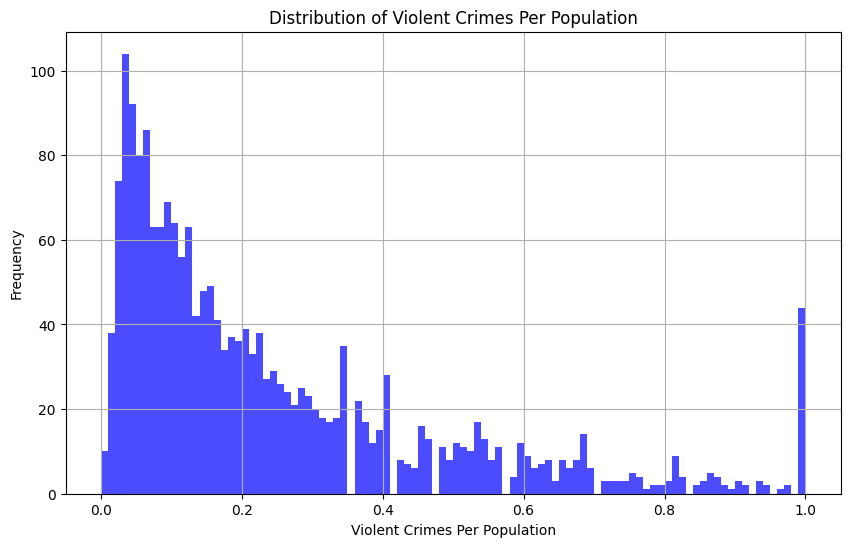

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(df['ViolentCrimesPerPop'], bins=100, color='blue', alpha=0.7)
plt.title('Distribution of Violent Crimes Per Population')
plt.xlabel('Violent Crimes Per Population')
plt.grid(True)
plt.ylabel('Frequency')

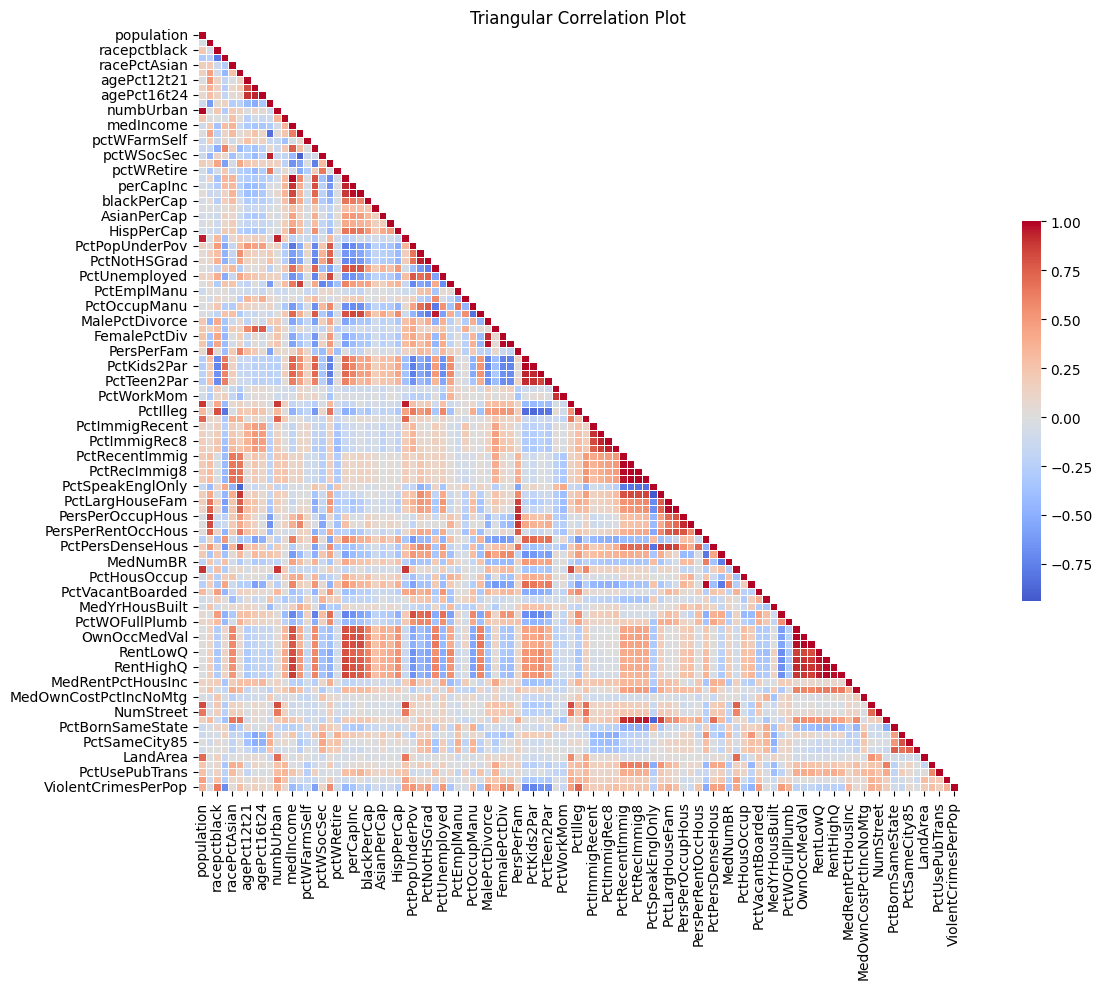

In [38]:
import seaborn as sns

# Create a triangular correlation plot
plt.figure(figsize=(14, 10))
correlation_matrix = quant_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.title('Triangular Correlation Plot')
plt.tight_layout()
plt.show()

From the plots above, we see that the distribution of violent crimes is heavily right skewed, and within the variables given, there are a number of highly correlated variables.

### Model Training
#### Unregularized Linear Regression

In [39]:
X_train, X_test, y_train, y_test = train_test_split(quant_df.drop('ViolentCrimesPerPop', axis=1), quant_df['ViolentCrimesPerPop'], test_size=0.2, random_state=48)

scaler = StandardScaler().fit(X_train)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

clf = sm.OLS(y_train, X_train).fit()
print(clf.summary())

y_pred = clf.predict(X_test)
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")


                             OLS Regression Results                            
Dep. Variable:     ViolentCrimesPerPop   R-squared:                       0.697
Model:                             OLS   Adj. R-squared:                  0.677
Method:                  Least Squares   F-statistic:                     34.42
Date:                 Fri, 22 May 2026   Prob (F-statistic):          2.24e-317
Time:                         15:02:55   Log-Likelihood:                 1012.3
No. Observations:                 1595   AIC:                            -1823.
Df Residuals:                     1494   BIC:                            -1280.
Df Model:                          100                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2398      0.003     72.26

### Lasso Regression

In [40]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV()
lasso = LassoCV(cv=5, random_state=48).fit(X_train, y_train)
print(f"Best alpha: {lasso.alpha_}")
print(f"Test R²:    {lasso.score(X_test, y_test):.4f}")

y_pred = lasso.predict(X_test)

print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")


Best alpha: 0.0005316217224050515
Test R²:    0.6619
Test RMSE: 0.1348
Test R²:   0.6619


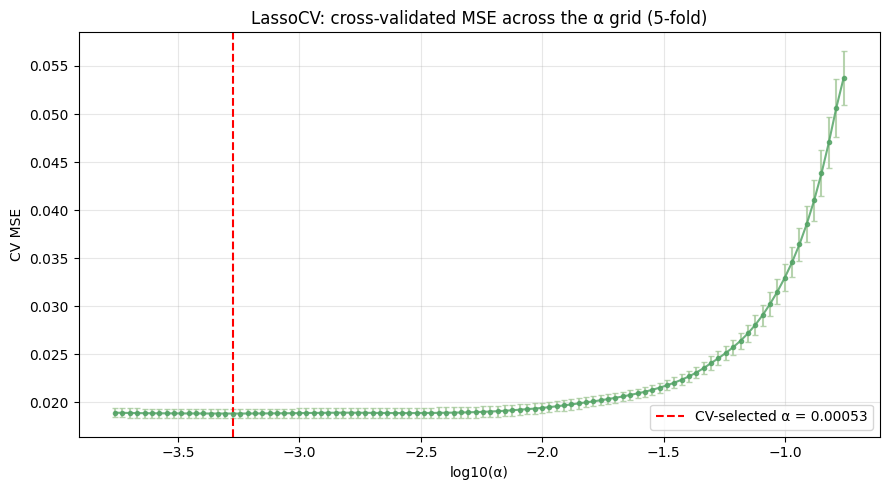

In [41]:
# Plot: LassoCV cross-validated MSE across the alpha grid
# Shows the trade-off curve and where CV selected the optimum.
mean_mse = lasso.mse_path_.mean(axis=1)
se_mse = lasso.mse_path_.std(axis=1, ddof=1) / np.sqrt(lasso.mse_path_.shape[1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(np.log10(lasso.alphas_), mean_mse, yerr=se_mse,
            fmt='o-', markersize=3, color='#55a467', ecolor='#aacca0',
            capsize=2, alpha=0.85, linewidth=1.5)
ax.axvline(np.log10(lasso.alpha_), color='red', linestyle='--',
           label=f'CV-selected α = {lasso.alpha_:.5f}')
ax.set_xlabel('log10(α)'); ax.set_ylabel('CV MSE')
ax.set_title('LassoCV: cross-validated MSE across the α grid (5-fold)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [42]:
for i, coef in zip(quant_df.drop('ViolentCrimesPerPop', axis=1).columns, lasso.coef_):
    print(f"Feature {i}: {coef}") if coef != 0 else None
print(f"Intercept: {lasso.intercept_}")

Feature racePctWhite: 0.041655937244464966
Feature racePctHisp: -0.0026905063290986885
Feature agePct12t21: 0.00043386579904700496
Feature agePct12t29: 0.004825806211040015
Feature agePct16t24: -0.0387560370405106
Feature medIncome: 0.013748733716883814
Feature pctWFarmSelf: -0.020870020351114727
Feature pctWInvInc: 0.006654160818574408
Feature pctWSocSec: -0.03056004356301529
Feature pctWPubAsst: 0.008949798878918459
Feature pctWRetire: -0.0004902909020627745
Feature medFamInc: -0.010238048957626625
Feature blackPerCap: -0.010939339944589212
Feature indianPerCap: -0.00039304385360739704
Feature AsianPerCap: -0.00511061248365822
Feature OtherPerCap: 0.0038062091528223816
Feature HispPerCap: 0.006447515103236853
Feature NumUnderPov: 0.002572197981265159
Feature PctPopUnderPov: -0.0036097477449872576
Feature PctLess9thGrade: -0.01238775074536896
Feature PctNotHSGrad: -0.007906352989780914
Feature PctEmploy: -0.006543815369343998
Feature PctEmplManu: 0.023574656797003553
Feature PctEmplPr

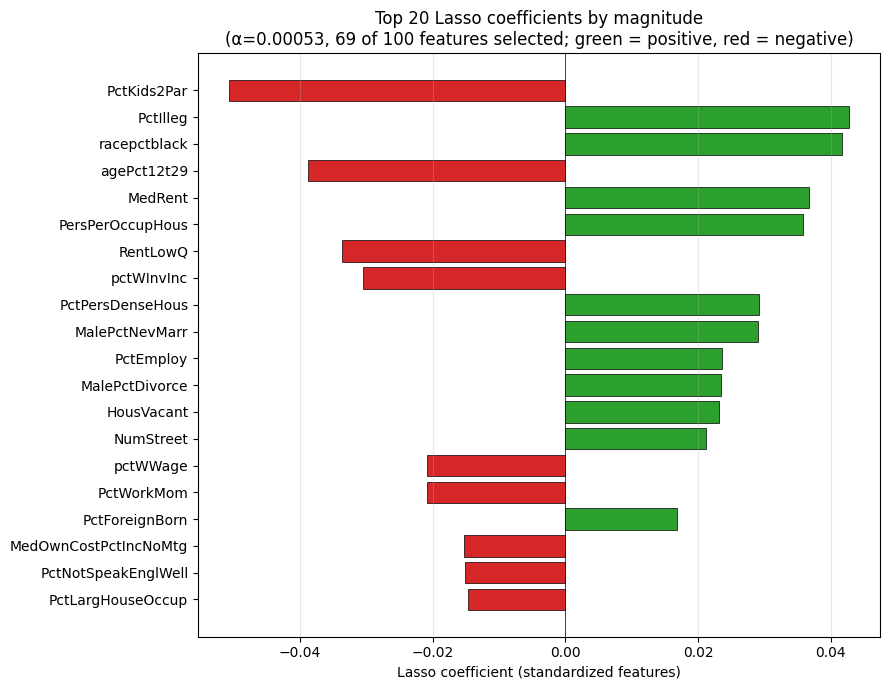

In [43]:
# Plot: top Lasso coefficients by magnitude.
# Note: lasso.coef_ has length 101 (X_train includes the constant column at
# index 0), so we slice [1:] to align with the 100 feature names.
feature_names = quant_df.drop('ViolentCrimesPerPop', axis=1).columns.tolist()
lasso_coefs = np.asarray(lasso.coef_)[1:]  # skip the constant column's coefficient

nz_mask = lasso_coefs != 0
nz = pd.Series(lasso_coefs[nz_mask],
               index=[n for n, m in zip(feature_names, nz_mask) if m])
top_n = 20
top_lasso = nz.reindex(nz.abs().sort_values(ascending=False).head(top_n).index)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in top_lasso.values]
ax.barh(top_lasso.index[::-1], top_lasso.values[::-1],
        color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Lasso coefficient (standardized features)')
ax.set_title(f'Top {top_n} Lasso coefficients by magnitude\n'
             f'(α={lasso.alpha_:.5f}, {int(nz_mask.sum())} of {len(feature_names)} features selected; '
             'green = positive, red = negative)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

### Elastic Net

In [44]:
from sklearn.linear_model import ElasticNetCV

elastic_net_cv = ElasticNetCV(cv=5, random_state=48).fit(X_train, y_train)
print(f"Best alpha: {elastic_net_cv.alpha_}")
print(f"Test R²:    {elastic_net_cv.score(X_test, y_test):.4f}")

y_pred = elastic_net_cv.predict(X_test)

print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")

Best alpha: 0.0010632434448101032
Test R²:    0.6618
Test RMSE: 0.1349
Test R²:   0.6618


In [45]:
en_tuned = ElasticNetCV(
    l1_ratio=[.1, .3, .5, .7, .9, .95, .99, 1.0],
    n_alphas=200, eps=1e-5,
    cv=RepeatedKFold(n_splits=10, n_repeats=3, random_state=48),
    random_state=48, max_iter=20000, n_jobs=-1,
).fit(X_train, y_train)

print(f"Selected alpha:     {en_tuned.alpha_:.5f}")
print(f"Selected l1_ratio:  {en_tuned.l1_ratio_:.2f}")
print(f"Active features:    {(en_tuned.coef_ != 0).sum()} / {len(en_tuned.coef_)}")
y_pred = en_tuned.predict(X_test)
print(f"\nTest R²:   {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

/Users/yiyangyu/Documents/UChicago_FinMath/Multivariate_Project_32950/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Selected alpha:     0.00252
Selected l1_ratio:  0.10
Active features:    81 / 101

Test R²:   0.6624
Test RMSE: 0.1347


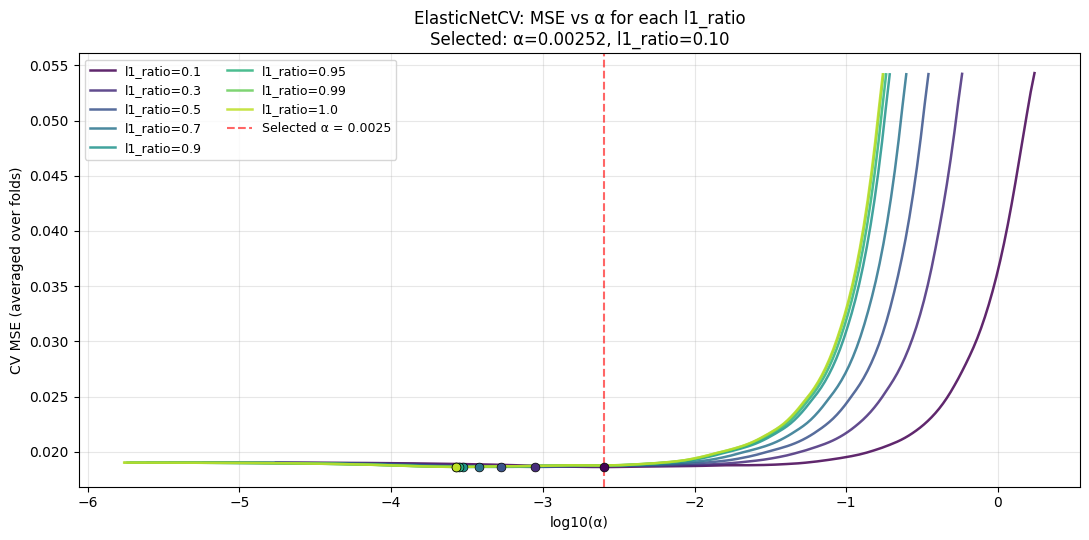


Observation: at small α, all l1_ratio values give nearly identical CV MSE.
The MSE flatness in this region is why the gap between Lasso (l1=1.0)
and Ridge-like (l1=0.1) is tiny on this dataset.


In [46]:
# Plot: ElasticNet CV MSE curves, one per l1_ratio value tested.
# This visualizes the entire 2D hyperparameter search (α × l1_ratio).
en_mse_path = en_tuned.mse_path_         # shape: (n_l1_ratios, n_alphas, n_folds)
en_alphas_grid = en_tuned.alphas_         # shape: (n_l1_ratios, n_alphas)
l1_ratios_tested = [.1, .3, .5, .7, .9, .95, .99, 1.0]
mean_mse_en = en_mse_path.mean(axis=2)

fig, ax = plt.subplots(figsize=(11, 5.5))
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(l1_ratios_tested)))
for i, l1 in enumerate(l1_ratios_tested):
    ax.plot(np.log10(en_alphas_grid[i]), mean_mse_en[i], '-',
            color=cmap[i], label=f'l1_ratio={l1}', linewidth=1.8, alpha=0.85)
    i_min = np.argmin(mean_mse_en[i])
    ax.scatter(np.log10(en_alphas_grid[i, i_min]), mean_mse_en[i, i_min],
               color=cmap[i], s=40, zorder=5, edgecolor='black', linewidth=0.5)

ax.axvline(np.log10(en_tuned.alpha_), color='red', linestyle='--', alpha=0.6,
           label=f'Selected α = {en_tuned.alpha_:.4f}')
ax.set_xlabel('log10(α)'); ax.set_ylabel('CV MSE (averaged over folds)')
ax.set_title(f'ElasticNetCV: MSE vs α for each l1_ratio\n'
             f'Selected: α={en_tuned.alpha_:.5f}, l1_ratio={en_tuned.l1_ratio_:.2f}')
ax.legend(loc='upper left', ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nObservation: at small α, all l1_ratio values give nearly identical CV MSE.")
print(f"The MSE flatness in this region is why the gap between Lasso (l1=1.0)")
print(f"and Ridge-like (l1=0.1) is tiny on this dataset.")

### Model Comparison

In [47]:
from sklearn.pipeline import Pipeline

rkf = RepeatedKFold(n_splits=10, n_repeats=5, random_state=48)

X_all = quant_df.drop('ViolentCrimesPerPop', axis=1)
y_all = quant_df['ViolentCrimesPerPop'].values

def cv_r2(model):
    pipe = Pipeline([('sc', StandardScaler()), ('m', model)])
    return cross_val_score(pipe, X_all.values, y_all, cv=rkf,
                          scoring='r2', n_jobs=-1)

r2_ols = cv_r2(LinearRegression())
r2_las = cv_r2(LassoCV(cv=5, random_state=48, max_iter=10000))
r2_en  = cv_r2(ElasticNetCV(cv=5, random_state=48, max_iter=10000))
r2_rdg = cv_r2(RidgeCV(alphas=np.logspace(-3, 2, 30)))

results = pd.DataFrame({
    'OLS':         r2_ols, 'Ridge': r2_rdg,
    'Lasso':       r2_las, 'ElasticNet': r2_en,
}).agg(['mean', 'std']).T
results.columns = ['CV R² mean', 'CV R² std']
print(results.round(4))

# Paired t-tests against OLS
print('\nPaired t-tests vs OLS (across 50 folds):')
for name, scores in [('Ridge', r2_rdg), ('Lasso', r2_las), ('ElasticNet', r2_en)]:
    t, p = stats.ttest_rel(scores, r2_ols)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f'  {name:12s} mean gap = {(scores-r2_ols).mean():+.4f}   t={t:+.2f}  p={p:.3f} {sig}')

            CV R² mean  CV R² std
OLS             0.6512     0.0536
Ridge           0.6558     0.0528
Lasso           0.6552     0.0538
ElasticNet      0.6552     0.0537

Paired t-tests vs OLS (across 50 folds):
  Ridge        mean gap = +0.0046   t=+4.52  p=0.000 ***
  Lasso        mean gap = +0.0040   t=+2.95  p=0.005 **
  ElasticNet   mean gap = +0.0040   t=+2.93  p=0.005 **


### Visualizations of Final Results

The plots below summarize the conclusions:
1. Model comparison — distribution of R² across all 50 CV folds, plus the paired-difference distribution showing that regularized methods give small but statistically detectable improvements over OLS (mean Δ ≈ 0.004 R²).
2. Coefficient comparison — OLS coefficients are visibly inflated by multicollinearity (e.g., `PersPerOccupHous` ≈ 0.14 in OLS vs. ≈ 0.04 in Lasso/EN). After shrinkage, Lasso and ElasticNet agree closely, giving more stable feature interpretation.
3. Diagnostics — predicted-vs-actual and residual plots. The residual variance grows clearly with the fitted value, confirming heteroskedasticity. Predictions also occasionally fall outside [0, 1], a sign that the linear model is partially misspecified for a bounded target.

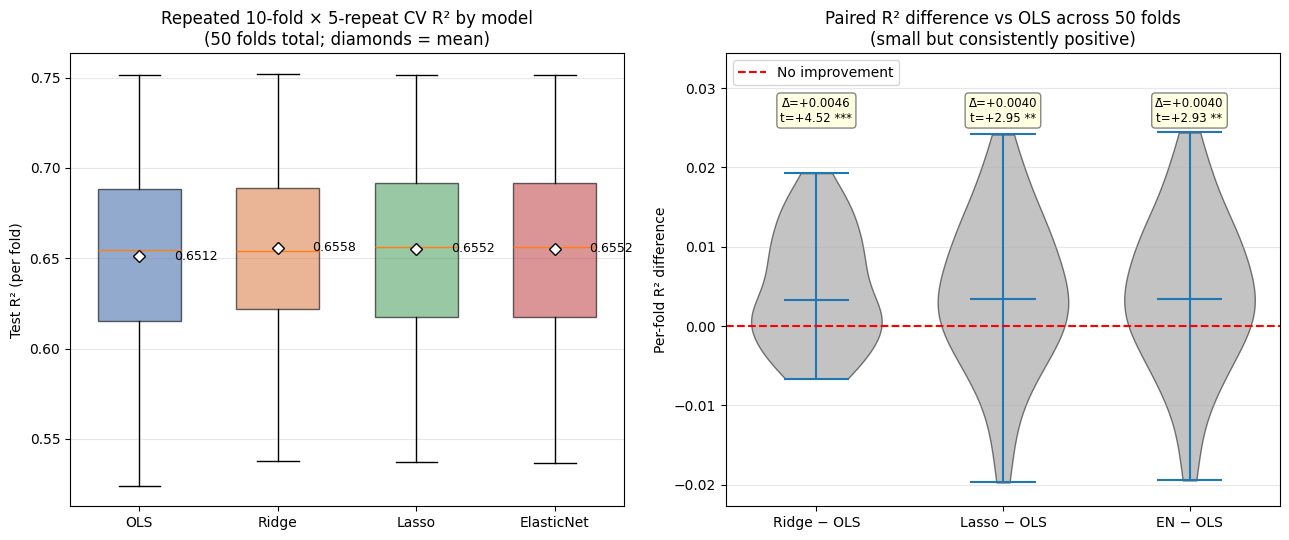

In [48]:
# Plot: R² distribution across 50 CV folds (10-fold × 5 repeats) per model.
# Left panel shows absolute R² spread; right panel shows paired differences vs OLS.
from scipy import stats as sps

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: per-model R² boxplot
data = [r2_ols, r2_rdg, r2_las, r2_en]
labels = ['OLS', 'Ridge', 'Lasso', 'ElasticNet']
bp = axes[0].boxplot(data, tick_labels=labels, patch_artist=True, widths=0.6,
                     showmeans=True,
                     meanprops={'marker': 'D', 'markerfacecolor': 'white',
                                'markeredgecolor': 'black', 'markersize': 6})
for patch, color in zip(bp['boxes'], ['#4c72b0', '#dd8452', '#55a467', '#c44e52']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[0].set_ylabel('Test R² (per fold)')
axes[0].set_title('Repeated 10-fold × 5-repeat CV R² by model\n(50 folds total; diamonds = mean)')
axes[0].grid(axis='y', alpha=0.3)
for i, m in enumerate([s.mean() for s in data]):
    axes[0].annotate(f'{m:.4f}', xy=(i+1, m), xytext=(i+1.25, m),
                     fontsize=9, va='center')

# Right: paired R² differences vs OLS
diffs = {'Ridge − OLS': r2_rdg - r2_ols,
         'Lasso − OLS': r2_las - r2_ols,
         'EN − OLS':    r2_en  - r2_ols}
positions = np.arange(len(diffs))
parts = axes[1].violinplot([diffs[k] for k in diffs], positions=positions,
                           showmedians=True, widths=0.7)
for pc in parts['bodies']:
    pc.set_facecolor('#888'); pc.set_alpha(0.5); pc.set_edgecolor('black')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='No improvement')
axes[1].set_xticks(positions); axes[1].set_xticklabels(list(diffs.keys()))
axes[1].set_ylabel('Per-fold R² difference')
axes[1].set_title('Paired R² difference vs OLS across 50 folds\n(small but consistently positive)')
axes[1].grid(axis='y', alpha=0.3); axes[1].legend(loc='upper left')

y_max = max(diffs[k].max() for k in diffs)
for i, k in enumerate(diffs):
    t, p = sps.ttest_rel(diffs[k] + r2_ols, r2_ols)
    mean = diffs[k].mean()
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    axes[1].annotate(f'Δ̄={mean:+.4f}\nt={t:+.2f} {sig}',
                     xy=(i, y_max + 0.001), ha='center', va='bottom',
                     fontsize=8.5,
                     bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow',
                               ec='gray', alpha=0.95))
axes[1].set_ylim(min(diffs[k].min() for k in diffs) - 0.003, y_max + 0.010)

plt.tight_layout(); plt.show()

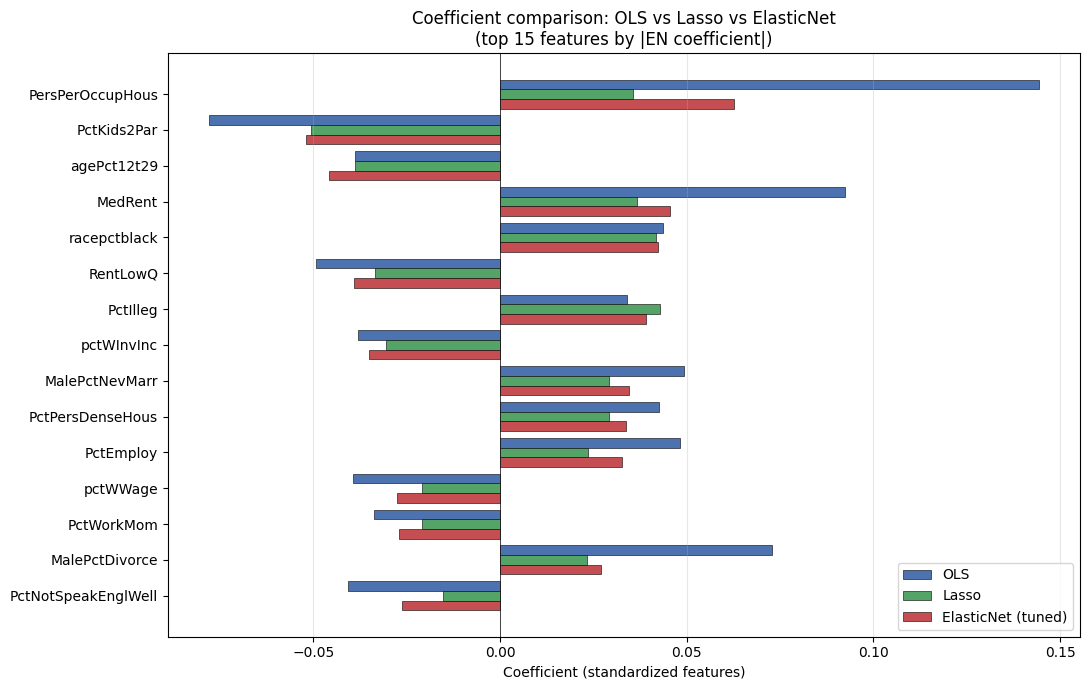

OLS  max |coefficient|: 0.144
Lasso max |coefficient|: 0.051
EN    max |coefficient|: 0.063

OLS coefficient magnitudes are inflated by collinearity (e.g. PersPerOccupHous);
Lasso and EN agree closely after shrinkage, giving more stable interpretation.


In [ ]:

feature_names = quant_df.drop('ViolentCrimesPerPop', axis=1).columns.tolist()

# All three models were fit on X_train which has a leading const column,
# so slice [1:] from each coefficient vector.
ols_coefs   = np.asarray(clf.params)[1:]
lasso_coefs = np.asarray(lasso.coef_)[1:]
en_coefs    = np.asarray(en_tuned.coef_)[1:]

top_idx = np.argsort(np.abs(en_coefs))[::-1][:15]
top_names = [feature_names[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(11, 7))
ypos = np.arange(len(top_idx)); width = 0.27
ax.barh(ypos - width, ols_coefs[top_idx],   width, label='OLS',
        color='#4c72b0', edgecolor='black', linewidth=0.4)
ax.barh(ypos,         lasso_coefs[top_idx], width, label='Lasso',
        color='#55a467', edgecolor='black', linewidth=0.4)
ax.barh(ypos + width, en_coefs[top_idx],    width, label='ElasticNet (tuned)',
        color='#c44e52', edgecolor='black', linewidth=0.4)
ax.set_yticks(ypos); ax.set_yticklabels(top_names); ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (standardized features)')
ax.set_title('Coefficient comparison: OLS vs Lasso vs ElasticNet\n(top 15 features by |EN coefficient|)')
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


print(f"OLS  max |coefficient|: {np.abs(ols_coefs).max():.3f}")
print(f"Lasso max |coefficient|: {np.abs(lasso_coefs).max():.3f}")
print(f"EN    max |coefficient|: {np.abs(en_coefs).max():.3f}")
print(f"\nOLS coefficient magnitudes are inflated by collinearity (e.g. PersPerOccupHous);")
print(f"Lasso and EN agree closely after shrinkage, giving more stable interpretation.")

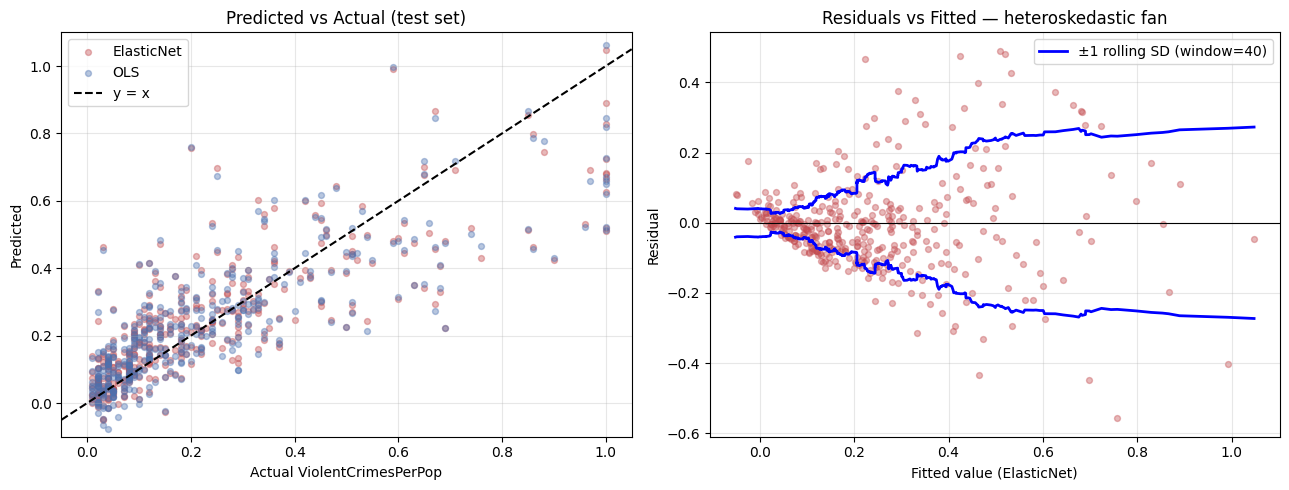

In [ ]:

y_pred_en  = en_tuned.predict(X_test)
y_pred_ols = clf.predict(X_test)
resid_en   = y_test - y_pred_en

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: predicted vs actual
axes[0].scatter(y_test, y_pred_en, alpha=0.4, s=18, color='#c44e52', label='ElasticNet')
axes[0].scatter(y_test, y_pred_ols, alpha=0.4, s=18, color='#4c72b0', label='OLS')
axes[0].plot([-0.05, 1.05], [-0.05, 1.05], 'k--', label='y = x')
axes[0].set_xlim(-0.05, 1.05); axes[0].set_ylim(-0.1, 1.1)
axes[0].set_xlabel('Actual ViolentCrimesPerPop'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual (test set)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: residuals vs fitted with rolling SD band
y_test_arr = np.asarray(y_test)
order = np.argsort(y_pred_en)
yp_sorted = y_pred_en[order]; re_sorted = resid_en.values[order] if hasattr(resid_en, 'values') else resid_en[order]
roll_std = pd.Series(re_sorted).rolling(40, min_periods=10, center=True).std()
axes[1].scatter(y_pred_en, resid_en, alpha=0.4, s=18, color='#c44e52')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].plot(yp_sorted, +roll_std, color='blue', linewidth=2,
             label='±1 rolling SD (window=40)')
axes[1].plot(yp_sorted, -roll_std, color='blue', linewidth=2)
axes[1].set_xlabel('Fitted value (ElasticNet)'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Fitted — heteroskedastic fan')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Conclusion: 

The repeated-CV evaluation and paired t-tests show that on this dataset, all four linear models perform within ≈0.5% of each other on test R². Ridge, Lasso, and ElasticNet do beat OLS by a statistically detectable margin (mean +0.004 R², t > 2.9), but the per-fold standard deviation (≈0.05) is more than ten times this gap, so the practical predictive advantage of regularization is negligible on data of this size and structure.What *does* differ meaningfully is coefficient stability: OLS produces inflated, unstable coefficients on collinear features (variables like `PersPerOccupHous`, `MedRent`, `MalePctDivorce`), while Lasso and ElasticNet shrink these toward a smaller, more interpretable common solution. For an interpretation-driven application — identifying which community-level features actually associate with violent crime — the regularized models are the right choice even though their predictive edge is modest.The diagnostics also flag two limitations of the linear specification itself: residual variance increases sharply with the fitted value (heteroskedasticity), and predictions can fall outside the bounded [0, 1] support of the target. Addressing these would require either a heteroskedasticity-robust inference layer (HC3 standard errors) or a model that respects the bounded support (e.g., beta regression or a censored-regression approach for the 2.2% of observations top-coded at 1.0).